(429435, 67)
(429435, 8)
location                   0
date                       0
total_cases            17631
new_cases              19276
total_deaths           17631
new_deaths             18827
total_vaccinations    344018
population                 0
dtype: int64
<StringArray>
[        'Afghanistan',              'Africa',             'Albania',
             'Algeria',      'American Samoa',             'Andorra',
              'Angola',            'Anguilla', 'Antigua and Barbuda',
           'Argentina',
 ...
             'Vatican',           'Venezuela',             'Vietnam',
               'Wales',   'Wallis and Futuna',      'Western Sahara',
               'World',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 255, dtype: str
(8382, 8)


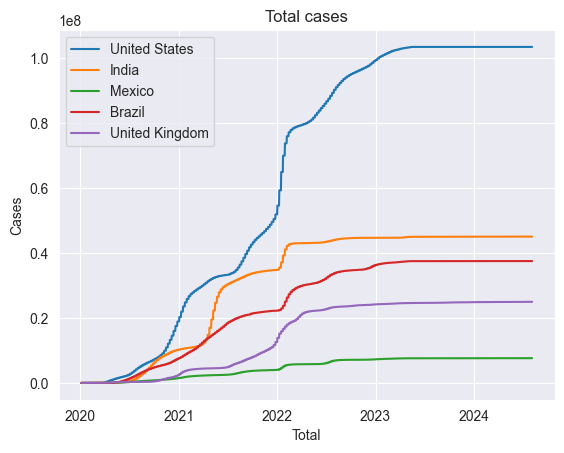

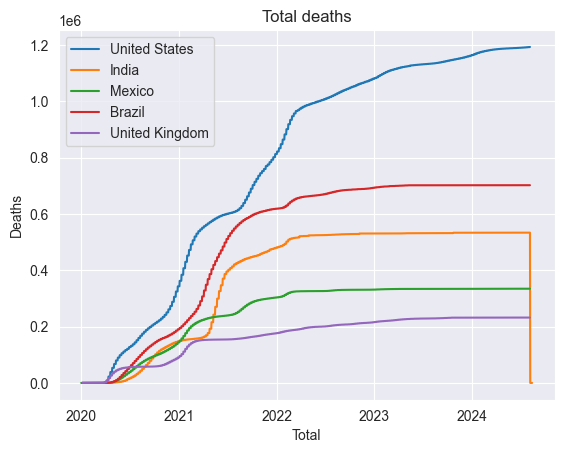

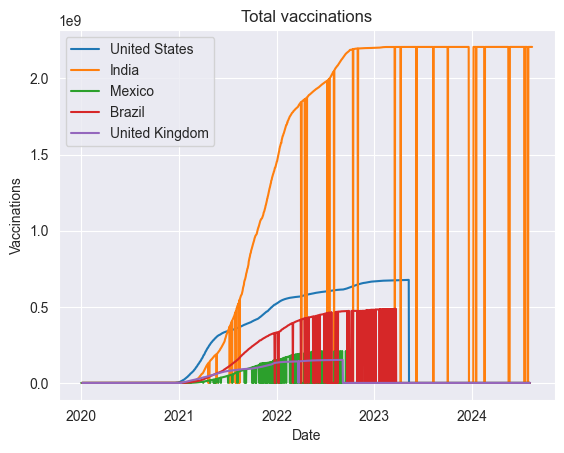

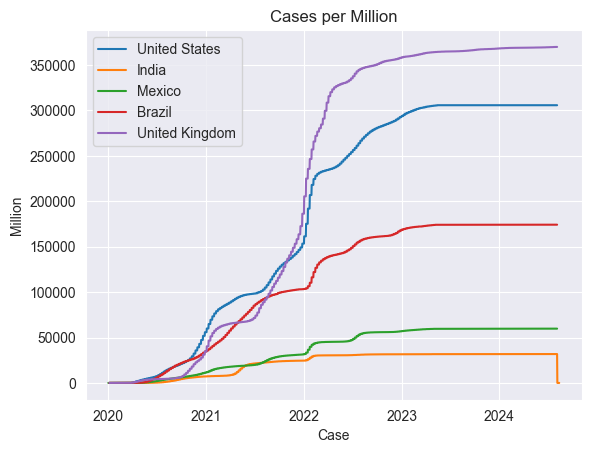

R2 Score: 0.91


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score




url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

important_cols = ['location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'total_vaccinations', 'population']
df = df[important_cols]
print(df.shape)
df.head()

print(df.isnull().sum())
print(df["location"].unique())

countries = ["United States", "India", "Mexico", "Brazil", "United Kingdom"]
df_countries = df[df["location"].isin(countries)]
print(df_countries.shape)

df_countries["date"] = pd.to_datetime(df_countries["date"])

for country in countries:
    data = df_countries[df_countries["location"] == country]
    plt.plot(data["date"], data["total_cases"], label=country)

df_countries['total_cases'] = df_countries['total_cases'].fillna(0)

plt.title("Total cases")
plt.xlabel("Total")
plt.ylabel("Cases")
plt.legend()
plt.show()

df_countries["total_deaths"] = df_countries["total_deaths"].fillna(0)

for country in countries:
    data = df_countries[df_countries["location"] == country]
    plt.plot(data["date"], data["total_deaths"], label=country)

plt.title("Total deaths")
plt.xlabel("Total")
plt.ylabel("Deaths")
plt.legend()
plt.show()

df_countries["total_vaccinations"] = df_countries["total_vaccinations"].fillna(0)

for country in countries:
    data = df_countries[df_countries["location"] == country]
    plt.plot(data["date"], data["total_vaccinations"], label=country)

plt.title("Total vaccinations")
plt.xlabel("Date")
plt.ylabel("Vaccinations")
plt.legend()
plt.show()

df_countries['cases_per_million'] = df_countries['total_cases'] / df_countries['population'] * 1000000

for country in countries:
    data = df_countries[df_countries["location"] == country]
    plt.plot(data["date"], data["cases_per_million"], label=country)

plt.title("Cases per Million")
plt.xlabel("Case")
plt.ylabel("Million")
plt.legend()
plt.show()

usa = df_countries[df_countries["location"] == "United States"].copy()

usa["day_num"] = range(len(usa))

X = usa[["day_num"]]
y = usa["total_cases"].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
score = r2_score(y_test, model.predict(X_test))
print(f"R2 Score: {score:.2f}")


## Vaccination Rollout
India led total vaccinations by a significant margin,
reflecting its massive population (1.4 billion) and
position as the world's largest vaccine manufacturer.
This highlights how raw numbers must be interpreted
in context of population size.


# COVID-19 Data Analysis 🦠

## Description
Analysis of real COVID-19 data across 5 major countries
examining cases, deaths, vaccinations and ML prediction.

## Tech Stack
- Python (Pandas, Matplotlib)
- Scikit-learn (Linear Regression R2=0.91)
- Jupyter Notebook
- Real OWID COVID-19 dataset

## Key Findings
- USA led in total cases and deaths
- India led in total vaccinations (population effect)
- UK had highest cases per million (fairer comparison)
- Linear Regression achieved R2=0.91 predicting case trends

## How to run
Open covid_analysis.ipynb in Jupyter

## COVID-19 Cases by Country
The United States recorded the highest total COVID-19 cases
among the analyzed countries, followed by Brazil and India.
The exponential growth visible from 2020-2021 reflects the
pandemic's rapid spread before vaccines became available.

## COVID-19 Deaths by Country
The United States also recorded the highest total deaths,
consistent with having the most cases. Brazil showed
disproportionately high deaths relative to its case count,
suggesting differences in healthcare capacity or reporting.

# COVID-19 Data Analysis 🦠

## Description
Analysis of real COVID-19 data across 5 major countries
examining cases, deaths, vaccinations and ML prediction.

## Tech Stack
- Python (Pandas, Matplotlib)
- Scikit-learn (Linear Regression R2=0.91)
- Jupyter Notebook
- Real OWID COVID-19 dataset

## Key Findings
- USA led in total cases and deaths
- India led in total vaccinations (population effect)
- UK had highest cases per million (fairer comparison)
- Linear Regression achieved R2=0.91 predicting case trends

## How to run
Open covid_analysis.ipynb in Jupyter